In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [9]:
CONFIG = {
    "train_csv": "data/train_data.csv",
    "val_csv": "data/val_data.csv",
    "test_csv": "data/test_data.csv",
    "img_size": 224,
    "batch_size": 32,
    "num_epochs": 30,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": 0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "save_path": "best_model.pth"
}


print(f"Устройство: {CONFIG['device']}")

Устройство: cpu


In [10]:
#dataset
class PneumoniaDataset(Dataset):
    def __init__(self, csv_path, transform = None):

        self.df = pd.read_csv(csv_path)
        self.df["image_path"] = self.df["image_path"].str.replace("\\", os.sep).str.replace("/", os.sep)
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        img_path = self.df.iloc[index]["image_path"]
        label = int(self.df.iloc[index]["label"])

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [12]:
class ConvBlock(nn.Module):
    
    def __init__(self, in_ch, out_ch, pool = True):
        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size = 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]

        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)
        

class PneumoniaCNN(nn.Module):
    def __init__(self, dropout = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3, 32, pool = True),
            ConvBlock(32, 64, pool = True),
            ConvBlock(64, 128, pool = True),
            ConvBlock(128, 256, pool = True),
            ConvBlock(256, 512, pool = True)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)
    
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [13]:
def train_epoch(model, loader, criterion, optimizer, device, epoch, num_epochs):
    
    model.train()
    total_loss, correct, total = 0, 0, 0

    pbar = tqdm(loader,
                desc=f"Train {epoch:03d}/{num_epochs}")

    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(logits) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        pbar.set_postfix(loss=f"{total_loss/total:.4f}",
                         acc=f"{correct/total:.4f}")

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device, desc="Val"):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False)

    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.float().to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix(loss=f"{total_loss/total:.4f}",
                         acc=f"{correct/total:.4f}")

    auc = roc_auc_score(all_labels, all_probs)
    
    return total_loss / total, correct / total, auc

In [7]:
def plot_training(history, save_path = "training_curves.png"):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4))
    fig.suptitle("Обучение CNN", fontsize = 14, fontweight = "bold")

    metrics = [
        ("loss", "Loss (BCEWithLogits)", ["Train Loss", "Val Loss"]),
        ("acc", "Accuracy", ["Train Acc", "Val Acc"]),
        ("auc", "AUC-ROC (val)", ["Val AUC"])
    ]

    colors = ["#e74c3c", "#3498db", "#2ecc71"]

    for ax, (key, title, labels) in zip(axes, metrics):
        if key == "auc":
            ax.plot(history["val_auc"], color = colors[2], label = labels[0], linewidth = 2)

        else:
            ax.plot(history[f"train_{key}"], color = colors[0], label = labels[0], linewidth = 2)
            ax.plot(history[f"val_{key}"], color = colors[1], label = labels[1], linewidth = 2)

        ax.set_title(title)
        ax.set_xlabel("Эпоха")
        ax.legend()
        ax.grid(alpha = 0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi = 300, bbox_inches = "tight")
    plt.close()
    print("График сохранен")

def plot_confusion(y_true, y_pred, save_path = "confusion_matrix.png"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize = (5, 4))
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", ax = ax,
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истина")
    ax.set_title("Матрица ошибок (тест)")
    plt.savefig(save_path, dpi = 150, bbox_inches = "tight")
    plt.close()
    print("Матица ошибок сохранена")

In [14]:
device = CONFIG["device"]

train_ds = PneumoniaDataset(CONFIG["train_csv"], transform=train_transforms)
val_ds = PneumoniaDataset(CONFIG["val_csv"], transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=CONFIG["num_workers"])
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"])

print("Train: ", len(train_ds), " изображений")
print("Val: ", len(val_ds), " изображений")

model = PneumoniaCNN(dropout=0.5).to(device)
print("Параметров: ", count_params(model))

labels_arr = train_ds.df["label"].values
n_neg = (labels_arr == 0).sum()
n_pos = (labels_arr == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], device=device)
print(f"pos_weight = {pos_weight.item():.2f}  (NORMAL={n_neg}, PNEUMONIA={n_pos})")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(),
                       lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
sheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"])

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "val_auc": []
}

best_val_auc = 0.0

epoch_bar = tqdm(range(1, CONFIG["num_epochs"] + 1),
                 desc="Эпохи", unit="ep")

for epoch in epoch_bar:
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device, epoch, CONFIG["num_epochs"]
    )
    val_loss, val_acc, val_auc = eval_epoch(
        model, val_loader, criterion, device, desc=f"Val {epoch:03d}/{CONFIG['num_epochs']}"
    )
    sheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    epoch_bar.set_postfix(
        tr_loss=f"{train_loss:.4f}",
        tr_acc=f"{train_acc:.4f}",
        val_auc=f"{val_auc:.4f}",
        best=f"{best_val_auc:.4f}",
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CONFIG["save_path"])
        tqdm.write(f"Epoch {epoch:03d} - новый лучший AUC ={best_val_auc:.4f}, модель сохранена")

print(f"Обучение завершено, лучший Val AUC: {best_val_auc:.4f}")
plot_training(history)


Train:  4644  изображений
Val:  1173  изображений
Параметров:  1701153
pos_weight = 0.37  (NORMAL=1244, PNEUMONIA=3400)


Эпохи:   0%|          | 0/30 [00:00<?, ?ep/s]

Эпохи:   3%|▎         | 1/30 [06:13<3:00:20, 373.12s/ep, best=0.0000, tr_acc=0.8288, tr_loss=0.2041, val_auc=0.9289]

Epoch 001 - новый лучший AUC =0.9289, модель сохранена


Эпохи:   7%|▋         | 2/30 [12:21<2:52:55, 370.56s/ep, best=0.9289, tr_acc=0.8835, tr_loss=0.1450, val_auc=0.9767]

...

Epoch 021 - новый лучший AUC =0.9897, модель сохранена


Эпохи:  77%|███████▋  | 23/30 [2:13:05<40:28, 346.92s/ep, best=0.9897, tr_acc=0.9593, tr_loss=0.0587, val_auc=0.9905]

Epoch 023 - новый лучший AUC =0.9905, модель сохранена


Эпохи: 100%|██████████| 30/30 [2:53:21<00:00, 346.73s/ep, best=0.9905, tr_acc=0.9686, tr_loss=0.0465, val_auc=0.9903]


Обучение завершено, лучший Val AUC: 0.9905
График сохранен


In [15]:
device = CONFIG["device"]

val_ds = PneumoniaDataset(CONFIG["val_csv"], transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"],
                        shuffle=False, num_workers=CONFIG["num_workers"])

model = PneumoniaCNN(dropout=0.5).to(device)
model.load_state_dict(torch.load(CONFIG["save_path"], map_location=device))
print(f"Модель загружена из {CONFIG['save_path']}")
print(f"Val датасет: {len(val_ds)} изображений")

train_ds_tmp = PneumoniaDataset(CONFIG["train_csv"])
labels_arr   = train_ds_tmp.df["label"].values
pos_weight   = torch.tensor([(labels_arr == 0).sum() / (labels_arr == 1).sum()], device=device)
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

val_loss, val_acc, val_auc = eval_epoch(model, val_loader, criterion, device, desc="Validation")

print(f"\nVal Loss : {val_loss:.4f}")
print(f"Val Acc : {val_acc:.4f}")
print(f"Val AUC : {val_auc:.4f}")

Модель загружена из best_model.pth
Val датасет: 1173 изображений



Val Loss : 0.0845
Val Acc : 0.9275
Val AUC : 0.9905


In [17]:
device = CONFIG["device"]

test_ds     = PneumoniaDataset(CONFIG["test_csv"], transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"],
                         shuffle=False, num_workers=CONFIG["num_workers"])

model = PneumoniaCNN(dropout=0.5).to(device)
model.load_state_dict(torch.load(CONFIG["save_path"], map_location=device))
model.eval()
print(f"Модель загружена из {CONFIG['save_path']}")
print(f"Test датасет: {len(test_ds)} изображений")

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)

test_auc = roc_auc_score(all_labels, all_probs)
print(f"\nTest AUC : {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=["NORMAL", "PNEUMONIA"]))

plot_confusion(all_labels, all_preds)

Модель загружена из best_model.pth
Test датасет: 23 изображений


Testing:   0%|          | 0/1 [00:00<?, ?it/s]

Testing: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


Test AUC : 1.0000

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00         8
   PNEUMONIA       1.00      1.00      1.00        15

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

Матица ошибок сохранена


Модель загружена из best_model.pth
Выбрано снимков: 20
Аугментаций каждый: 5
Итого предсказаний: 100


TTA:   0%|          | 0/20 [00:00<?, ?it/s]

TTA: 100%|██████████| 20/20 [00:03<00:00,  6.27it/s]


Всего предсказаний : 100
Правильных         : 99
TTA Accuracy       : 0.9900
TTA AUC-ROC        : 1.0000

Точность по типу аугментации:
              верно  всего  accuracy
augmentation                        
bright+          19     20      0.95
h_flip           20     20      1.00
original         20     20      1.00
rot_+10          20     20      1.00
rot_-10          20     20      1.00


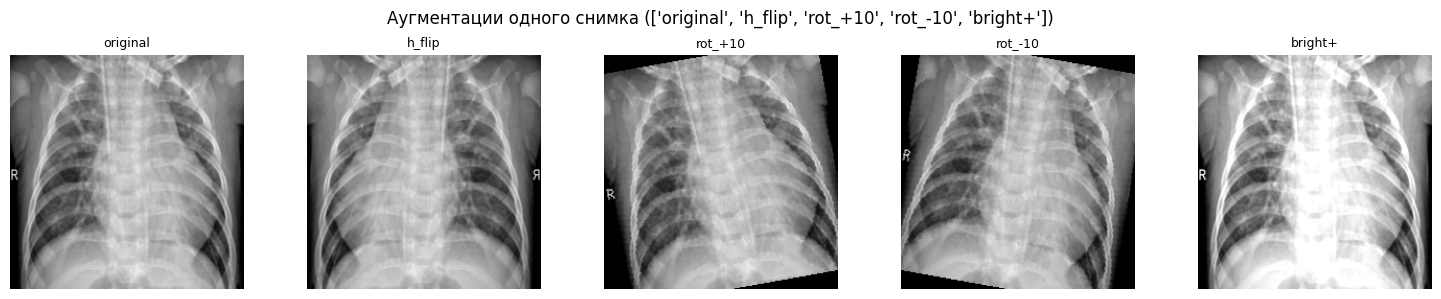

Примеры аугментаций сохранены: tta_examples.png


In [28]:
import random

N_IMAGES  = 20 
N_AUGS    = 5 

SEED      = 42

tta_transforms = [

    transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.ColorJitter(brightness=(1.3, 1.3)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
]

assert len(tta_transforms) == N_AUGS, "Количество трансформаций должно равняться N_AUGS"

device = CONFIG["device"]
model = PneumoniaCNN(dropout=0.5).to(device)
model.load_state_dict(torch.load(CONFIG["save_path"], map_location=device))
model.eval()
print(f"Модель загружена из {CONFIG['save_path']}")

test_df = pd.read_csv(CONFIG["test_csv"])
test_df["image_path"] = (test_df["image_path"]
    .str.replace("\\\\", os.sep, regex=False)
    .str.replace("/", os.sep, regex=False))

random.seed(SEED)
chosen_idx = random.sample(range(len(test_df)), N_IMAGES)
chosen_df  = test_df.iloc[chosen_idx].reset_index(drop=True)

print(f"Выбрано снимков: {N_IMAGES}")
print(f"Аугментаций каждый: {N_AUGS}")
print(f"Итого предсказаний: {N_IMAGES * N_AUGS}")

tta_records = []

with torch.no_grad():
    for i, row in tqdm(chosen_df.iterrows(), total=N_IMAGES, desc="TTA"):
        img_orig = Image.open(row["image_path"]).convert("RGB")
        true_label = int(row["label"])

        for aug_idx, tfm in enumerate(tta_transforms):
            img_tensor = tfm(img_orig).unsqueeze(0).to(device)
            logit = model(img_tensor)
            prob  = torch.sigmoid(logit).item()
            pred  = int(prob >= 0.5)

            tta_records.append({
                "image"     : os.path.basename(row["image_path"]),
                "aug_idx"   : aug_idx,
                "true_label": true_label,
                "prob"      : round(prob, 4),
                "pred"      : pred,
                "correct"   : int(pred == true_label),
            })

tta_df = pd.DataFrame(tta_records)

total_preds   = len(tta_df)
correct_preds = tta_df["correct"].sum()
tta_acc       = correct_preds / total_preds
tta_auc       = roc_auc_score(tta_df["true_label"], tta_df["prob"])

print(f"Всего предсказаний : {total_preds}")
print(f"Правильных         : {correct_preds}")
print(f"TTA Accuracy       : {tta_acc:.4f}")
print(f"TTA AUC-ROC        : {tta_auc:.4f}")

aug_names = ["original", "h_flip", "rot_+10", "rot_-10", "bright+"]
tta_df["augmentation"] = tta_df["aug_idx"].map(dict(enumerate(aug_names)))

print("\nТочность по типу аугментации:")
print(tta_df.groupby("augmentation")["correct"]
      .agg(["sum", "count", "mean"])
      .rename(columns={"sum": "верно", "count": "всего", "mean": "accuracy"})
      .round(4))

fig, axes = plt.subplots(1, N_AUGS, figsize=(3 * N_AUGS, 3))
fig.suptitle(f"Аугментации одного снимка ({aug_names})", fontsize=12)

sample_img = Image.open(chosen_df.iloc[0]["image_path"]).convert("RGB")
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for ax, tfm, name in zip(axes, tta_transforms, aug_names):
    t = tfm(sample_img)      
    t = t * std + mean        
    t = t.clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(t, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("tta_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Примеры аугментаций сохранены: tta_examples.png")


C:\Users\m_shi\AppData\Local\Temp\ipykernel_13856\3168781548.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


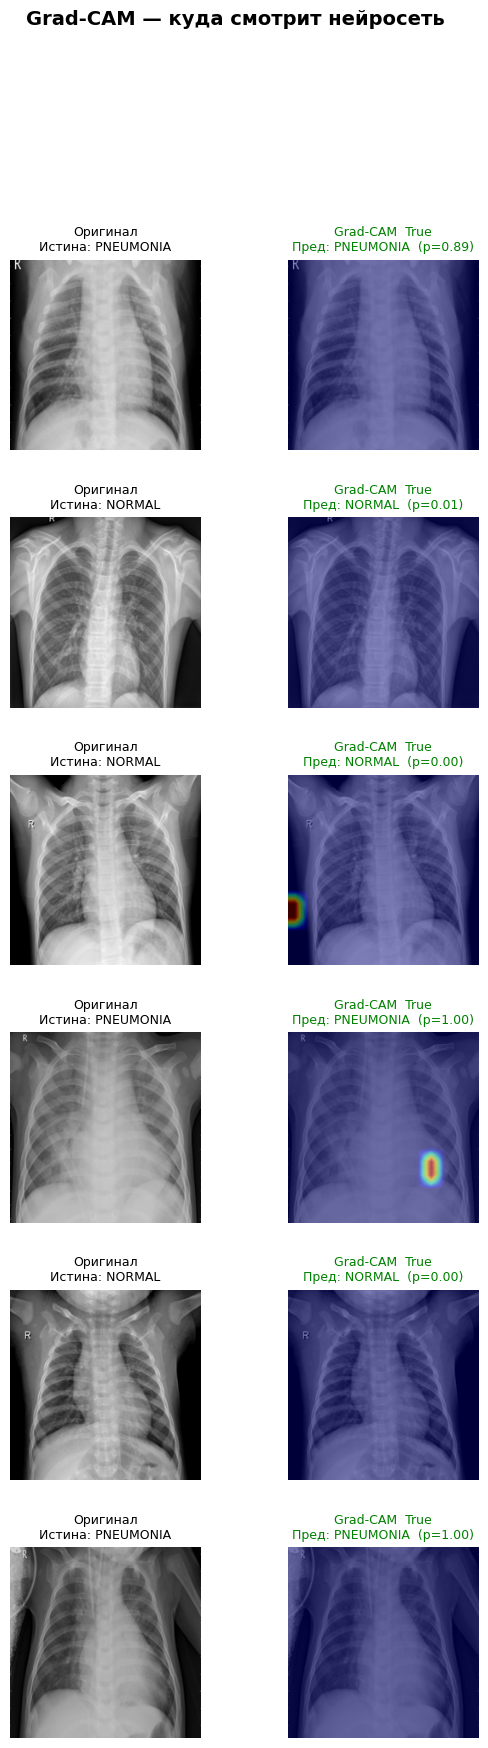

In [27]:
N_SAMPLES = 6
SEED      = 0
random.seed(SEED)

device = CONFIG["device"]
model  = PneumoniaCNN(dropout=0.5).to(device)
model.load_state_dict(torch.load(CONFIG["save_path"], map_location=device))
model.eval()

target_layer = model.features[-1].block[0]

fmaps, grads = [], []

def fwd_hook(module, inp, out):
    fmaps.clear()
    fmaps.append(out.detach())

def bwd_hook(module, grad_in, grad_out):
    grads.clear()
    grads.append(grad_out[0].detach())

h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)

def get_gradcam(img_pil):
    tfm = transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    x = tfm(img_pil).unsqueeze(0).to(device)

    model.zero_grad()
    logit = model(x)
    logit.backward()

    weights = grads[0].mean(dim=(2, 3), keepdim=True)
    cam = (weights * fmaps[0]).sum(dim=1).squeeze()
    cam = torch.relu(cam)

    p_low  = torch.quantile(cam, 0.20)
    p_high = torch.quantile(cam, 0.95)
    cam = (cam - p_low) / (p_high - p_low + 1e-8)
    cam = cam.clamp(0, 1)

    return cam.cpu().numpy()

def overlay(img_pil, cam):
    img_rgb = img_pil.resize((CONFIG["img_size"], CONFIG["img_size"])).convert("RGB")
    img_np  = np.array(img_rgb) / 255.0

    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize(
            (CONFIG["img_size"], CONFIG["img_size"]), Image.BILINEAR
        )
    ) / 255.0

    heatmap = cm.jet(cam_resized)[..., :3]
    blended = 0.55 * img_np + 0.45 * heatmap
    return np.clip(blended, 0, 1)

test_df = pd.read_csv(CONFIG["test_csv"])
test_df["image_path"] = (test_df["image_path"]
    .str.replace("\\\\", os.sep, regex=False)
    .str.replace("/",  os.sep, regex=False))

normal    = test_df[test_df["label"] == 0].sample(N_SAMPLES // 2, random_state=SEED)
pneumonia = test_df[test_df["label"] == 1].sample(N_SAMPLES // 2, random_state=SEED)
chosen    = pd.concat([normal, pneumonia]).sample(frac=1, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(N_SAMPLES, 2,
                         figsize=(7, 3.2 * N_SAMPLES),
                         gridspec_kw={"wspace": 0.05, "hspace": 0.35})
fig.suptitle("Grad-CAM — куда смотрит нейросеть", fontsize=14, fontweight="bold", y=1.01)

label_names = {0: "NORMAL", 1: "PNEUMONIA"}

for i, row in chosen.iterrows():
    img_pil    = Image.open(row["image_path"]).convert("RGB")
    true_label = int(row["label"])

    tfm = transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    with torch.no_grad():
        prob = torch.sigmoid(model(tfm(img_pil).unsqueeze(0).to(device))).item()
    pred = int(prob >= 0.5)

    cam     = get_gradcam(img_pil)
    blended = overlay(img_pil, cam)

    img_show = img_pil.resize((CONFIG["img_size"], CONFIG["img_size"]))

    axes[i, 0].imshow(img_show, cmap="gray")
    axes[i, 0].set_title(f"Оригинал\nИстина: {label_names[true_label]}", fontsize=9)
    axes[i, 0].axis("off")

    correct = "True" if pred == true_label else "False"
    color   = "green" if pred == true_label else "red"
    axes[i, 1].imshow(blended)
    axes[i, 1].set_title(
        f"Grad-CAM  {correct}\nПред: {label_names[pred]}  (p={prob:.2f})",
        fontsize=9, color=color
    )
    axes[i, 1].axis("off")

h1.remove()
h2.remove()

plt.tight_layout()
plt.show()
